In [1]:
%matplotlib inline

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:01<00:00, 89.8MB/s]


  dog plane  ship   cat


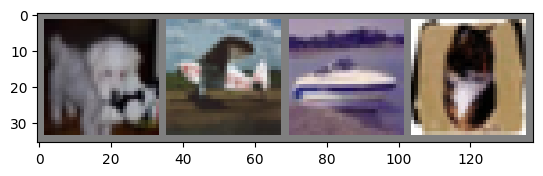

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)


# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

In [5]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class ChannelGate(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(ChannelGate, self).__init__()
        # if gate_channels // reduction_ratio == 0: #fixed for mobileNetV2
        #     reduction_ratio = gate_channels
        self.mlp = nn.Sequential(
            Flatten(),
            nn.Linear(gate_channels, gate_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(gate_channels // reduction_ratio, gate_channels)
            )
    def forward(self, x):
        squeeze_avg = F.avg_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
        channel_att = self.mlp(squeeze_avg)
        scale = torch.sigmoid(channel_att).unsqueeze(2).unsqueeze(3).expand_as(x)
        return x * scale

class SE(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(SE, self).__init__()
        self.ChannelGate = ChannelGate(gate_channels, reduction_ratio)
    def forward(self, x):
        x_out = self.ChannelGate(x)
        return x_out

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ===== PDP BLOCK =====
class PDPBlock(nn.Module):
    def __init__(self, in_channels, out_channels, s):
        super(PDPBlock, self).__init__()

        self.pw1 = nn.Conv2d(in_channels, in_channels, 1)
        self.dw1 = nn.Conv2d(in_channels, in_channels, 3, stride=s, padding=1, groups=in_channels)
        self.dw2 = nn.Conv2d(in_channels, in_channels, 3, stride=s, padding=2, dilation=2, groups=in_channels)

        self.pw2 = nn.Conv2d(2 * in_channels, out_channels, 1)
        self.bn = nn.BatchNorm2d(out_channels)

        self.SE = SE(out_channels)

        self.s = s
        self.PwR = nn.Conv2d(in_channels, out_channels, 1, stride=s)

    def shuffle(self, x):
        b, c, h, w = x.size()
        g = 2
        x = x.view(b, g, c // g, h, w)
        x = x.permute(0, 2, 1, 3, 4).contiguous()
        x = x.view(b, c, h, w)
        return x

    def forward(self, x):
        pw1 = self.pw1(x)

        dw1 = F.relu(self.dw1(pw1))
        dw2 = F.relu(self.dw2(pw1))

        dw = torch.cat([dw1, dw2], dim=1)
        dw = self.shuffle(dw)

        out = self.pw2(dw)
        out = self.SE(out)
        out = self.bn(out)

        if self.s == 1 and x.size() == out.size():
            out = x + out
        else:
            out = F.relu(self.PwR(x)) + out

        return F.relu(out)


# ===== FINAL MODEL =====
class NetFinal(nn.Module):
    def __init__(self, n_class=10):
        super(NetFinal, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.block1 = PDPBlock(32, 64, 1)
        self.block2 = PDPBlock(64, 64, 1)
        self.block3 = PDPBlock(64, 128, 2)
        self.block4 = PDPBlock(128, 128, 1)
        self.block5 = PDPBlock(128, 256, 2)
        self.block6 = PDPBlock(256, 256, 1)
        self.block7 = PDPBlock(256, 256, 1)
        self.block8 = PDPBlock(256, 512, 2)
        self.block9 = PDPBlock(512, 512, 1)

        self.conv2 = nn.Conv2d(512, 1024, 1)
        self.bn2 = nn.BatchNorm2d(1024)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(1024, n_class)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.block7(x)
        x = self.block8(x)
        x = self.block9(x)

        x = F.relu(self.bn2(self.conv2(x)))

        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        return self.fc(x)

net = NetFinal(n_class=10)
net.to(device)
from torchsummary import summary
print(net)
summary(net, (3, 32, 32))

NetFinal(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): PDPBlock(
    (pw1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (dw1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
    (dw2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2), groups=32)
    (pw2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (SE): SE(
      (ChannelGate): ChannelGate(
        (mlp): Sequential(
          (0): Flatten()
          (1): Linear(in_features=64, out_features=4, bias=True)
          (2): ReLU()
          (3): Linear(in_features=4, out_features=64, bias=True)
        )
      )
    )
    (PwR): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (block2): PDPBlock(
    (pw1): Conv2d(64, 64, kernel_si

In [7]:
import torchvision
import torchvision.transforms as transforms

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True, num_workers=2)

testloader = torch.utils.data.DataLoader(testset, batch_size=100,
                                         shuffle=False, num_workers=2)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = NetFinal(n_class=10).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.SGD(net.parameters(),
                            lr=0.1,
                            momentum=0.9,
                            weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

In [9]:
history = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": []
}

best_acc = 0

for epoch in range(200):

    # ===== TRAIN =====
    net.train()
    running_loss, correct, total = 0, 0, 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 5)
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total

    # ===== TEST =====
    net.eval()
    test_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_loss /= len(testloader)
    test_acc = 100 * correct / total

    scheduler.step()

    # ===== SAVE =====
    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(net.state_dict(), "best_model.pth")

    # ===== PRINT =====
    lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/200] | LR: {lr:.5f} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

print("Finished Training")
print("Best Test Accuracy:", best_acc)

Epoch [1/200] | LR: 0.09999 | Train Loss: 2.1232 | Train Acc: 28.58% | Test Loss: 6.1391 | Test Acc: 30.61%
Epoch [2/200] | LR: 0.09998 | Train Loss: 1.7643 | Train Acc: 42.88% | Test Loss: 1.7314 | Test Acc: 48.85%
Epoch [3/200] | LR: 0.09994 | Train Loss: 1.5507 | Train Acc: 52.89% | Test Loss: 1.4760 | Test Acc: 56.23%
Epoch [4/200] | LR: 0.09990 | Train Loss: 1.3738 | Train Acc: 60.74% | Test Loss: 1.3803 | Test Acc: 60.80%
Epoch [5/200] | LR: 0.09985 | Train Loss: 1.2562 | Train Acc: 66.39% | Test Loss: 1.2842 | Test Acc: 64.71%
Epoch [6/200] | LR: 0.09978 | Train Loss: 1.1627 | Train Acc: 70.95% | Test Loss: 1.1556 | Test Acc: 71.26%
Epoch [7/200] | LR: 0.09970 | Train Loss: 1.0767 | Train Acc: 74.88% | Test Loss: 1.1005 | Test Acc: 73.63%
Epoch [8/200] | LR: 0.09961 | Train Loss: 1.0301 | Train Acc: 77.17% | Test Loss: 1.1012 | Test Acc: 73.74%
Epoch [9/200] | LR: 0.09950 | Train Loss: 1.0049 | Train Acc: 78.26% | Test Loss: 1.0307 | Test Acc: 76.91%
Epoch [10/200] | LR: 0.09938

In [10]:
import matplotlib.pyplot as plt
def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # ===== LOSS =====
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # ===== ACC =====
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["test_acc"], label="Test Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    plt.tight_layout()
    plt.show()

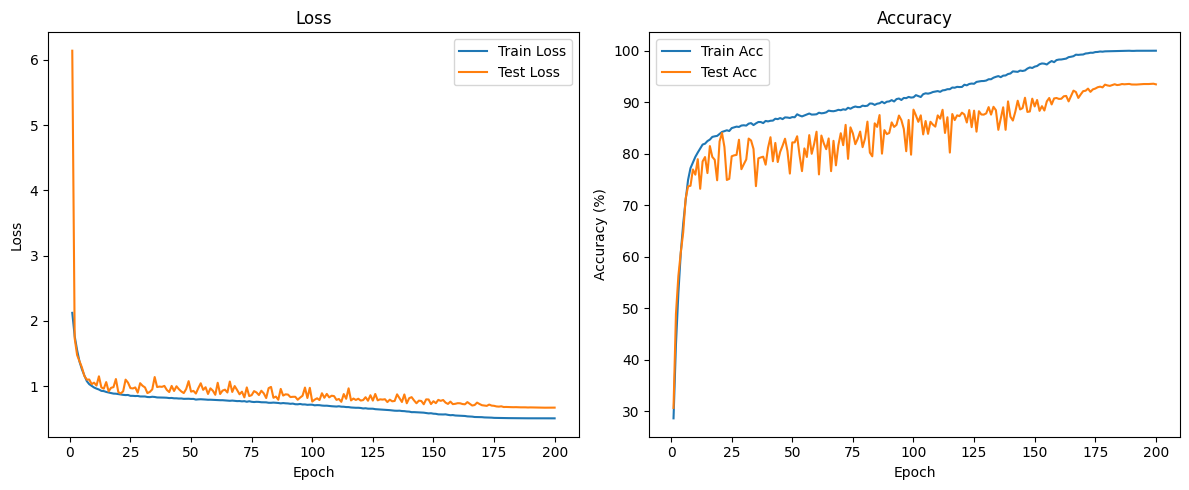

In [11]:
plot_history(history)